# Predicting the Unpredictable
# Task 4 - Report Notebook

Use this template as a guide to writing your final report notebooks. Please write **one notebook per task**.

General instructions:
- **We will not run these notebooks when marking them!** Please run these notebooks yourselves before you save them.
- You should **combine code, showcasing your data exploration, model design, and results, with written cells, explaining the motivation for your design choices and your results**. We are looking for reports which tell a clear and concise story, rather than simply dumping large amounts of code with undocumented cell outputs.
- Please use the main section headings, but feel free to add more subsections. See the tips below for more advice on what to include in each section.
- Please delete all the tips in this template before submitting (including these instructions).

# Introduction

In task 4, we predict the time and place of each lightning, using 36 frames of four images: visible (vis), water vapour(ir069), cloud/surface temperature(ir107), and vertically integrated liquid (vil). The output of model is array data of which size is (N, 3), where N = the number of lightning events and "3" means there are three data for each lightning(time[s], x-pixel and y-pixel in verticall integrated liquid image).

# Data Exploration

**1. Input dataset**  
   The input data is 36 frames recorded every 5 minutes of four images (vis, ir069, ir107, and vil). Note that vis and vil image are size of 384 x 384 while ir069 and ir107 are size of 192 x 192. (Fig.1)  
**2. Output dataset**  
   The output data is array of N $\times$ 5. (Fig.2) N is the total number of lightning in a single storm, and each lightning event has five information (time, latitude, longtitude, vil pixel x and vil pixel y).    
**3. Anomalies/peculiarities that might affect our performance**  
   The number of pixel points where lightning seems to have happened is much smaller than that of total pixels(384 x 384) as shown in Fig.2. So, the imbalance of output (target) data cannot be avoided. This will make it hard for our model to learn dataset appropriately.  

<div style="text-align:center">
<img src="dataset_format.jpg" width="600">
</div>
<div style="text-align:center">
Fig.1 Dataset format
</div>

<div style="text-align:center">
<img src="Task4_output_dataset_format.jpg" width="800">
</div>
<div style="text-align:center">
Fig.2 Data format of lightning data 
</div>

<div style="text-align:center">
<img src="total_pixel_to_lightning_place.jpg" width="800">
</div>
<div style="text-align:center">
Fig.3 Imbalance of lightning data
</div>

# Data Preprocessing

**1. Data preprocessing**  
   **(1)Upscaling ir069 and ir107 image**  
   It is necessary to upscale ir069 and ir107 images because the size of these data is 192x192 pixels while other two image data (vis and vil) are 384x384 pixels. We upscaled ir069 and ir107 data to 384x384 pixels with bilinear interpolation. (Fig.4)  
   **(2)Allocating lightning place to each frame image**  
   In our model, we predict where the lightning events occured at a specific time frame and place. Therefore, our prediction depends on the number of time frame (and thus, sampling rate). Default data has 36 frames in every 5 minutes for each strom event (Fig.5). The preprocessing step for output is following (Fig.6 shows the format of the target matrix) :    
    - Preapre 36 x 384 x 384 matrix  
    - Allocate each lightning to appropriate time frame (0-35) and to appropriate spacial pixel data ((x,y) = (0-383, 0-383))  
    - Clip the value to be between 0 and 1 to too large value causing imbalance in pixel value.  
**2. Train/test split**  
　we use first 80% of storm events for training, and the remains for testing

<div style="text-align:center">
<img src="Task4_upsample_to_384.jpg" width="600">
</div>
<div style="text-align:center">
Fig.4 Function for upsampling from 192 x 192 to 384 x 384
</div>

<div style="text-align:center">
<img src="Task4_mapping_lightning_to_channel.png" width="600">
</div>
<div style="text-align:center">
Fig.5 Allocating each lightning event to correspond time frame
</div>

<div style="text-align:center">
<img src="Task4_mapping_lightning_place.png" width="600">
</div>
<div style="text-align:center">
Fig.6 Format of target matrix for each storm event
</div>

# Metrics
There are four metrics usually used for clasification, namely, accuracy, recall, precision, and F1-score. Each definition is following.  
$$\mathrm{Accuracy} = \frac{TP}{TP + TN + FP + FN}$$  
$$\mathrm{recall} = \frac{TP}{TP + FN}$$
$$\mathrm{Precision} = \frac{TP}{TP+FP}$$
$$\mathrm{F1-socre} = 2\times\frac{\mathrm{Recall} \times \mathrm{Precision}}{\mathrm{Recall} + \mathrm{Precision}}$$  
where  
 　TP (True Positive): The model predict there is lightning at a specific pixel, and a lightning truly happened.  
 　TN (True Negative): The model predict there is not lightning at a specific pixcel, and lightning did not happened.  
 　FP (False Positive): The model predict there is lightning at a specific pixel but lightning did not happened.  
 　FN (False Ngative): The model predict there is not lightning at a specific pixel but lightning happned.  
In particular, in this work, we prioritize recall score because higher FN means the model is missing more lightning events, and it will be make the model more useless for a disaster or acciendent prediction. In addition, to evaluate the balance between recall and precision, we also evaluate F1-score.  

# Baseline Model

In essential, this task requires dictating a specific pixcel place that meets some criterion from input image. For this purpose, U-Net is an appropriate model. Therefore, as a base line model, we constructed simple two dimensional U-Net model. The U-net has three parts of convolutional layers for learning: encoding (feature extraction), bottleneck (capturing the most important information) and decoder (restoring the original image size). The typical structure is Fig.7. The baseline model is two-dimensional mode, and thus, convolition is implemented in spacial direction. 
For our baseline model, we use two layers for all parts for simplification, and the flow of number of channel is below.
- Encoder: (input_channel, 4) -> (4, 8)
- Bottleneck: (8, 16) -> (16, 16)
- Decoder: (16, 8) -> (8, 4)  
  
Other parameters are following:
- Optimizer: adam
- learning rate: 1e-4
- loss function: FocalLoss
- Epoch: 10  
- Size of dataset: 20% of all dataset for training and 5% for testing

<div style="text-align:center">
<img src="U-net.jpg" width="600">
</div>
<div style="text-align:center">
Fig.7 Basic structure of U-Net[1]
</div>
[1]Ronneberger, O., Fischer, P., Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. In: Navab, N., Hornegger, J., Wells, W., Frangi, A. (eds) Medical Image Computing and Computer-Assisted Intervention – MICCAI 2015. MICCAI 2015. Lecture Notes in Computer Science(), vol 9351. Springer, Cham. https://doi.org/10.1007/978-3-319-24574-4_28

# Baseline Model Results

**1. Performance of our baseline model**  
    Fig.8 shows the loss and performance of our baseline model at each epoch. As epoch increases, the loss decreases appropriately, and the model obtained high accuracy of about 0.995-0.966. However, the recall socre and F1 score are significantly low. Such trend (high accuracy but low recall and F1 score) may be the result of an imbalance between the number of lightning places and that of other places (lightning did not happened) largely affects the performance of our model. The number of lightning place is much smaller than that for not, and as a result, our model did not predict lightning event appropriately, leading to very low recall and F1 score. In this test, 20% of total dataset is used for training, and using more dataset may improve the performance.

<div style="text-align:center">
<img src="Task4_Result(U-Net).jpg" width="1200">
    <img src="Task4_Result(U-Net2D)_output_script.jpg" width="1200">
</div>
<div style="text-align:center">
Fig.8 Performance of baseline model
</div>

**2. Performance improvement by incrasing dataset**  
Table 1 shows the performance comparison between training with 20% of dataset and that with 80%. By using more dataset, our model still obtained high acuracy (~0.98), and recall score is significantly improved. So, our model can predict true lightning events more accurately. However, F1-score is still significantly low, meaning that precision should be improved more. In summary, using large dataset for training our baseline model can give our model good capability for predicting true lightning event but there are also many cases that our model predict false lightning event.  

<div style="text-align:center">
Table.1 performace comaprison of different training dataset size .
</div>

| Metrics for validation | Training dataset size = 20% | Training Dataset size = 80% |
|------------------------|-----------------------------|-----------------------------|
| Accuracy               | 0.996                       | 0.977                       |
| Recall                 | 0.002                       | 0.729                       |
| F1-score               | 0.001                       | 0.070                       |

# Model Extensions and Results
Tips:
- Based on the performance of your baseline, propose and justify extensions / other model architectures.
- Compare the performance of these models with your baseline.
- Visualise the outputs of the trained models.
- Describe key strengths/ limitations of these models.
- Report methods / results on any of the bonus tasks.

**1. Extension to U-Net 3D**  
**(a)Summary of extension**  
In our baseline model, the network learns features by convolution of 2D spacial information. However, hidden features naturally depends on time progress information (how the image changes as time evolves) in this task (i.e., how temperature changes after lightning).  Therefore, for the first step of extension, we extend our model from 2D U-Net to 3D U-Net. In 3D U-Net, convolusion at each layer is implemented toward both two spacial axis and time axis. With this 3D U-Net, we can expect our model can learn more valuable features.   

**(b)Performance of U-Net 3D**  
Fig.9 shows the sample output of loss, accuracy, f1 score and recall in our U-Net 3D model with training by 80% of full dataset and 6 epochs. Although this extenstion achieved lower accuracy, it obtained much higher recall score than that for our baseline model. This result means that this extension helped predicting true lightning events much more accurately while false positive (model predicts there is a lightning but not in real) is also increase. However, flase positive is much less harmuful than false negative as already mentioned, and considering a siginificant imbalance in lightning data, achieving higher recall score is more important than retaining accuracy with increase of false negative prediction. In addition, this result is obtained by 6 epoch of training which is smaller than baseline model (we reduced epochs because of computational cost of U-Net 3D). Therefore, we can conclude that our model is well improved from baseline model.

<div style="text-align:center">
<img src="Task4_Result(U-Net3D)_output_script.jpg" width="1200">
</div>
<div style="text-align:center">
Fig.9 Performance of U-Net3D
</div>

**(3)Key strength and limitation**  
As a key strength, our U-Net 3D has a siginificant advantage for recall score, meaning that it can properly predict lightning event. On the other hand, this extension did not help improving F1-score, essentially precision score. This means that this model has still weakness from the viewpoint of false positive. In addition, our model process lightning data at every time frame. In this case, our model can predict the time of lightning only in every 300 seconds (5 minutes), not a second unit. Improving this predicting rate (less than 300 seconds) is definitely the next improvement step. 

**2. Further improvement**

### Time‑Bucket Lightning Model – Inputs and Outputs

#### Input

For each storm, the model takes a 5D tensor:

- Shape: (B, T, C, H, W)
- Dimensions:
  - B: batch size
  - T: number of time steps (frames), here T = 36
  - C: number of input channels, here C = 4 (vis, ir069, ir107, vil)
  - H, W: spatial size, here H = 384, W = 384

So each sample is a sequence of 36 four‑channel images at 384×384 resolution.

---

#### Time‑Bucket Output Design

Each 5‑minute frame is split into finer time buckets:

- Frame duration: FRAME_DT = 300 seconds
- Bucket duration: BUCKET_DT = 10 seconds
- Number of buckets per frame: M = FRAME_DT / BUCKET_DT = 30

For every pixel in every frame, the model predicts a distribution over (M + 1) classes:

- Channels 0 … M−1 (the first M channels):
  - Each of these channels corresponds to a 10‑second lightning time bucket inside the frame.
  - Example:
    - channel 0  → lightning in [0, 10) seconds
    - channel 1  → lightning in [10, 20) seconds
    -...
    - channel 29 → lightning in [290, 300) seconds

- Channel M (the last channel):
  - Special "no‑flash" class, meaning no lightning occurs at this pixel during that 5‑minute frame.

---

#### Model Output Tensor

The network outputs logits with shape:

- (B, T, C_out, H, W)

where:

- C_out = M + 1 = 31

For each pixel (y, x) at time step t, the vector

- logits[b, t, :, y, x]

contains 31 scores:

- the first M scores for the lightning time buckets, and
- the last score for the no‑flash class.

After applying softmax over the channel dimension, this becomes a probability distribution that encodes both:

- whether lightning will occur (flash vs no‑flash), and
- roughly when it will occur within that 5‑minute frame (which time bucket).

**3. Scaling law of baseline model performance (optional)**  
    Fig.* shows the validation loss in different dataset size for training (20%, 30%, 60% and 80% of dataset). As generally expected, the model obtained small validation loss successfully. In our model, validation loss is approximately propotional to -0.028log10(dataset size). As already expected, our model is strognly affected by the imbalance of lightning place data. The dispersion from regression line may be caused by dispersion in number of lightning records in a single storm event.

<div style="text-align:center">
<img src="Task4_loss-samples.jpg" width="600">　　
</div>
<div style="text-align:center">
Fig.* Relationship between validation loss and dataset size for training
</div>

Our model can effectively solve the problems of accurate prediction time and data imbalance. Below are its training results. After several modifications to the hyperparameters in the loss function, all prediction results are displayed as probabilities, so we define a prediction threshold (the figure shows the version with threshold=0.7).

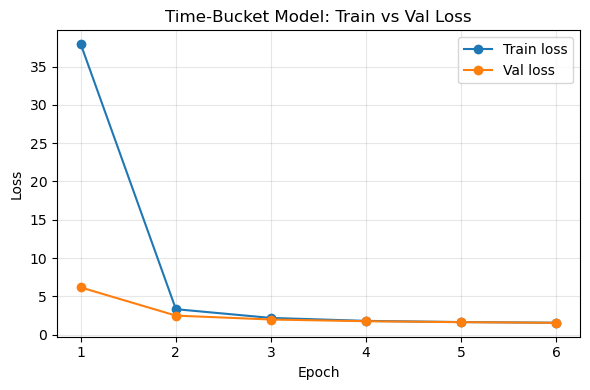
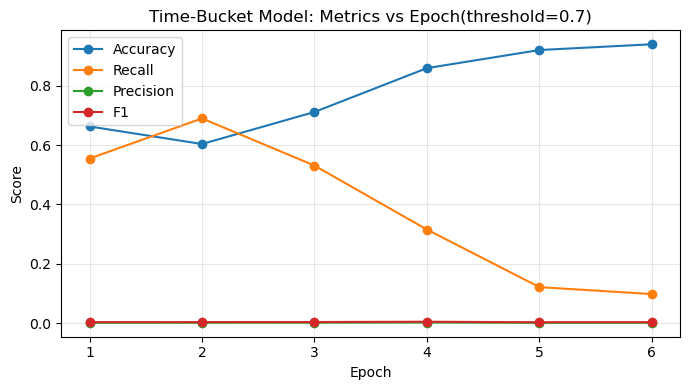

### Performance Trade-off Between Accuracy and Recall

We observed that the model has difficulty achieving high accuracy and high recall simultaneously, which leads to consistently low F1 scores. This issue primarily stems from the asymmetric cost of prediction errors in lightning detection.

Lightning strikes are sparse, point-like events. In order to avoid false negatives (i.e., missing true lightning strikes), the model tends to predict lightning in a broader surrounding area. While this strategy improves recall, it also increases the number of false positives, thereby reducing precision and overall accuracy. As a result, the F1 score remains low despite reasonable performance in individual metrics.

To address this challenge, we aim to adjust the model’s hyperparameters—such as classification thresholds and loss weighting—to better balance accuracy and recall. Our goal is to minimize false negatives while simultaneously preventing the overestimation of large spatial regions as lightning events, thus improving the overall F1 score.


# Discussion 

Tips:
- Summarise your work; discuss the overall strengths and limitations of your models, and key insights you have learned about the task.
- Propose future work you would do if you had more time.